# Between-cluster hyperedge removal

## Config — the only cell you need to edit

In [ ]:
CLUSTERS_FILE = r"MY_PATH\clustering_ML\data\synthetic_data\true_clusters\cluster_id1_low_noise.txt"

# One line per edge file. Either {legend label: path} or a plain list of paths
# (in which case the file stem is the label). All of them share CLUSTERS_FILE.
EDGES_FILES = {
    "Forman": r"MY_PATH\clustering_ML\results\synthetic_data\cluster_id1_low_noise\hyperedge_removal_Forman_clustering.txt",
    "OR_MMOT": r"MY_PATH\clustering_ML\results\synthetic_data\cluster_id1_low_noise\hyperedge_removal_OR_MMOT_clustering.txt",
    "random": r"MY_PATH\clustering_ML\results\synthetic_data\cluster_id1_low_noise\hyperedge_removal_random_clustering.txt",
}

RULES = ["strict", "majority"]           # within-cluster definitions to plot
METRICS = ["precision", "recall"]        # one figure per rule x metric
MAX_STEPS = None                         # e.g. 500 to only plot the first 500 removals
SHOW_BASELINE = True                     # grey reference lines for random / perfect orderings
NODE_ID_BASE = 1                         # node id of line 1 of a one-label-per-line cluster file
FIGSIZE = (7, 4.5)                       # size of each individual figure

## Setup

In [12]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def read_clusters(path, id_base=1):
    """Parse a cluster file into {node: cluster}.

    One label per line  -> the node id is the line number, offset by `id_base`.
    Two columns per line -> read as '<node> <cluster>'.
    """
    labels = {}
    for i, line in enumerate(Path(path).read_text().splitlines()):
        parts = line.replace(",", " ").split()
        if not parts:
            continue  # blank line, e.g. a trailing newline
        if len(parts) == 1:
            labels[i + id_base] = parts[0]
        else:
            labels[int(parts[0])] = parts[1]
    return labels


def read_edges(path):
    """Parse one hyperedge per line into a list of node lists, keeping file order."""
    edges = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split(maxsplit=1)
        node_field = parts[1] if len(parts) > 1 else parts[0]  # drop a leading index
        nodes = [int(t) for t in node_field.replace(" ", "").split(",") if t]
        if nodes:
            edges.append(nodes)
    return edges


def as_labelled(files):
    """Accept {label: path}, a list of paths, or one path -> {legend label: path}."""
    if isinstance(files, dict):
        return dict(files)
    if isinstance(files, (str, Path)):
        files = [files]
    stems = [Path(p).stem for p in files]
    return {(f"{Path(p).parent.name}/{s}" if stems.count(s) > 1 else s): p
            for p, s in zip(files, stems)}


def is_within(nodes, labels, rule):
    """True if the hyperedge lies within a cluster under the given rule.

    strict   — every node is labelled and shares one cluster.
    majority — one cluster holds strictly more than half the nodes (ties are between).
    Unlabelled nodes count towards the size but towards no cluster.
    """
    labs = [labels[n] for n in nodes if n in labels]
    if not labs:
        return False
    top = Counter(labs).most_common(1)[0][1]
    return top == len(nodes) if rule == "strict" else 2 * top > len(nodes)

## The analysis

In [13]:
def score(edges_path, clusters_path, rules=("strict", "majority"),
          max_steps=None, id_base=1, labels=None, quiet=False):
    """Per-step precision and recall of between-cluster removals for one edge file."""
    if labels is None:
        labels = read_clusters(clusters_path, id_base)
    edges = read_edges(edges_path)
    if max_steps:
        edges = edges[:max_steps]

    sizes = np.array([len(e) for e in edges])
    steps = np.arange(1, len(edges) + 1)
    df = pd.DataFrame({"step": steps, "cardinality": sizes}).set_index("step")

    if not quiet:
        print(f"  {len(edges)} hyperedges, cardinalities {sizes.min()}-{sizes.max()} "
              f"(mean {sizes.mean():.2f})")
        missing = {n for e in edges for n in e if n not in labels}
        if missing:
            print(f"  warning: {len(missing)} nodes have no cluster label "
                  f"(e.g. {sorted(missing)[:5]}) — check NODE_ID_BASE")

    for rule in rules:
        between = np.array([not is_within(e, labels, rule) for e in edges])
        found = np.cumsum(between)
        total = between.sum()
        df[f"between_{rule}"] = between
        df[f"frac_{rule}"] = found / steps                                  # precision
        df[f"recall_{rule}"] = found / total if total else 0.0              # recall
        if not quiet:
            print(f"  {rule:>8}: {total} / {len(edges)} between cluster "
                  f"(overall fraction {between.mean():.4f})")
    return df


TITLES = {
    "precision": ("frac", "Fraction of hyperedges removed that are between-cluster",
                  "Precision of removals"),
    "recall": ("recall", "fraction of all between-cluster hyperedges removed",
               "Recall of between-cluster hyperedges"),
}


def plot_metric(results, rule, metric, show_baseline=True, figsize=(7, 4.5)):
    col, ylabel, title = TITLES[metric]
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    colours = plt.get_cmap("tab10")

    for k, (name, df) in enumerate(results.items()):
        ax.plot(df.index.to_numpy(), df[f"{col}_{rule}"], lw=1.4,
                color=colours(k), label=name)

    if show_baseline:
        shapes = sorted({(int(df[f"between_{rule}"].sum()), len(df))
                         for df in results.values()})

    ax.set_xlabel("Number of hyperedges removed")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} — {rule}", fontsize=11)
    ax.set_xlim(1, max(len(df) for df in results.values()))
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3, lw=0.5)
    ax.legend(fontsize=8, title="edge file", title_fontsize=8)
    plt.show()
    return fig


def analyse(edges_files, clusters_path, rules=("strict", "majority"),
            metrics=("precision", "recall"), max_steps=None, show_baseline=True,
            id_base=1, figsize=(7, 4.5)):
    labels = read_clusters(clusters_path, id_base)
    print(f"{len(labels)} labelled nodes, {len(set(labels.values()))} clusters\n")

    results = {}
    for name, path in as_labelled(edges_files).items():
        print(f"{name}  [{Path(path).name}]")
        results[name] = score(path, clusters_path, rules, max_steps,
                              id_base, labels=labels)

    for rule in rules:
        for metric in metrics:
            plot_metric(results, rule, metric, show_baseline, figsize)

    return results

## Run

1000 labelled nodes, 3 clusters

Forman  [hyperedge_removal_Forman_clustering.txt]
  1430 hyperedges, cardinalities 2-4 (mean 2.77)
    strict: 127 / 1430 between cluster (overall fraction 0.0888)
  majority: 76 / 1430 between cluster (overall fraction 0.0531)
OR_MMOT  [hyperedge_removal_OR_MMOT_clustering.txt]
  1608 hyperedges, cardinalities 2-4 (mean 2.42)
    strict: 175 / 1608 between cluster (overall fraction 0.1088)
  majority: 131 / 1608 between cluster (overall fraction 0.0815)
random  [hyperedge_removal_random_clustering.txt]
  1693 hyperedges, cardinalities 2-4 (mean 2.49)
    strict: 138 / 1693 between cluster (overall fraction 0.0815)
  majority: 100 / 1693 between cluster (overall fraction 0.0591)


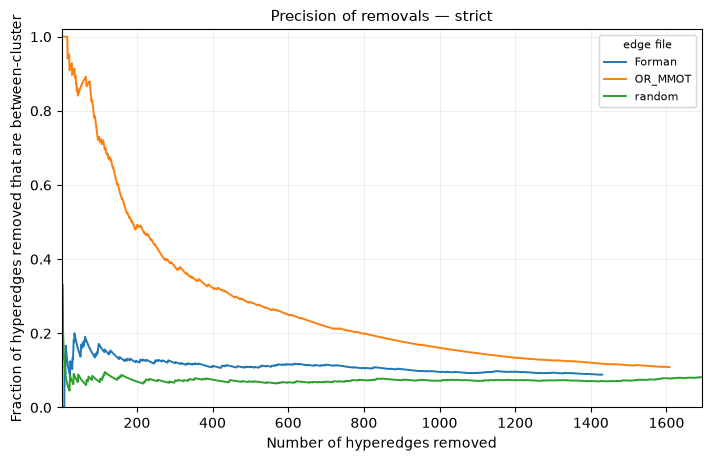

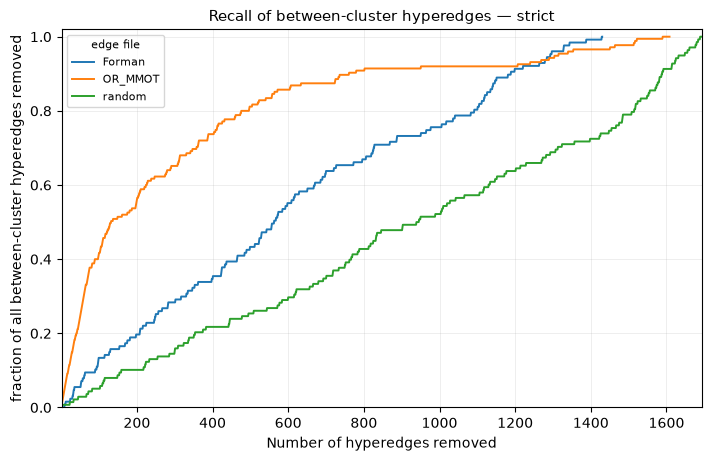

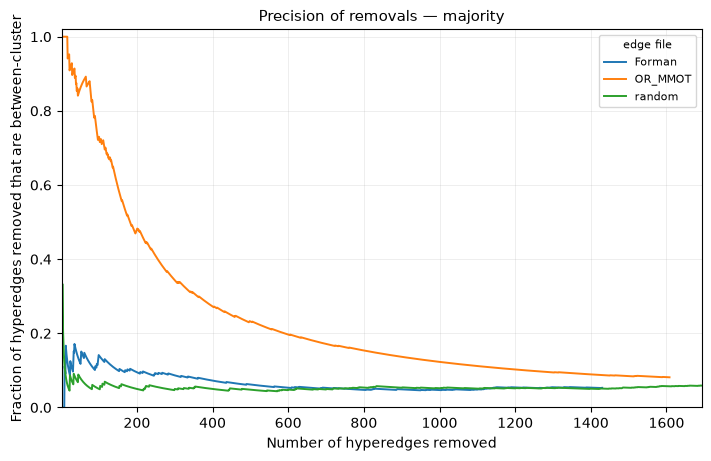

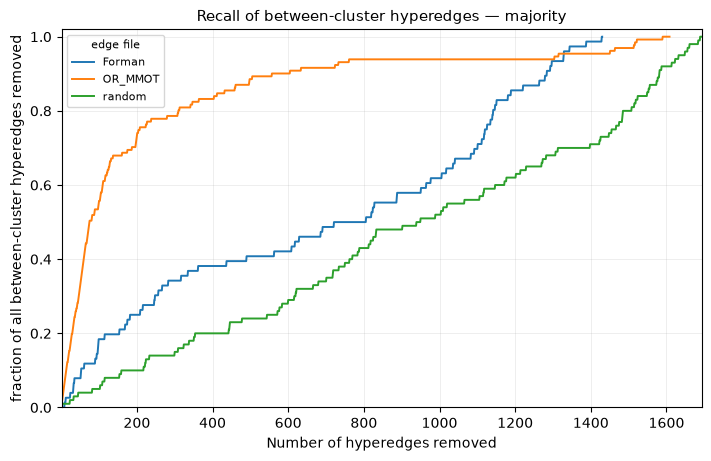

,cardinality,between_strict,frac_strict,recall_strict,between_majority,frac_majority,recall_majority
step,,,,,,,
1,4,False,0.0,0.0,False,0.0,0.0
2,4,False,0.0,0.0,False,0.0,0.0
3,4,False,0.0,0.0,False,0.0,0.0
4,4,False,0.0,0.0,False,0.0,0.0
5,4,False,0.0,0.0,False,0.0,0.0


In [14]:
results = analyse(EDGES_FILES, CLUSTERS_FILE, rules=RULES, metrics=METRICS,
                  max_steps=MAX_STEPS, show_baseline=SHOW_BASELINE,
                  id_base=NODE_ID_BASE, figsize=FIGSIZE)
next(iter(results.values())).head()

`results` is `{legend label: DataFrame}`, one frame per edge file, indexed by removal
step. Each holds the hyperedge cardinality and, per rule, a boolean for whether that
hyperedge was between cluster (`between_*`), the running precision (`frac_*`) and the
running recall (`recall_*`).

To add another ordering to the comparison, add a line to `EDGES_FILES` and re-run. To
redraw a single figure — say to save it — call `plot_metric` directly:

```python
fig = plot_metric(results, "strict", "recall")
fig.savefig("recall_strict.png", dpi=200)
```

In [15]:
# fraction between cluster broken down by hyperedge cardinality, per edge file
for name, df in results.items():
    cols = [c for c in df.columns if c.startswith("between_")]
    print(name)
    display(df.groupby("cardinality")[cols].agg(["mean", "size"]).round(4))

Forman


between_strict      between_majority     
                      mean size             mean size
cardinality                                          
2                   0.0690  609           0.0690  609
3                   0.0971  546           0.0165  546
4                   0.1164  275           0.0909  275

OR_MMOT


between_strict       between_majority      
                      mean  size             mean  size
cardinality                                            
2                   0.0922  1095           0.0922  1095
3                   0.1362   345           0.0261   345
4                   0.1607   168           0.1250   168

random


between_strict       between_majority      
                      mean  size             mean  size
cardinality                                            
2                   0.0713  1066           0.0713  1066
3                   0.0926   421           0.0166   421
4                   0.1117   206           0.0825   206